# ML

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
df = pd.read_csv('ml_model_data.csv')
display(df.head(3))

,batting_style,bowling_style,playing_role,is_capped_international,base_price_lakh,highest_auction_price_lakh,age,ipl_experience,log_highest_price
0,Right-hand bat,No Bowling,Batsman,1,75,100,44,10,4.615121
1,Right-hand bat,Slow left-arm orthodox,Bowler,0,100,405,34,8,6.006353
2,Right-hand bat,Left-arm fast,All-Rounder,1,20,105,23,1,4.663439


In [3]:
df['value_ratio'] = df['log_highest_price'] / (df['base_price_lakh'] + 1)

In [4]:
df.columns

Index(['batting_style', 'bowling_style', 'playing_role',
       'is_capped_international', 'base_price_lakh',
       'highest_auction_price_lakh', 'age', 'ipl_experience',
       'log_highest_price', 'value_ratio'],
      dtype='object')

In [5]:
# before encode
df['playing_role_original'] = df['playing_role']
df['bowling_style_original'] = df['bowling_style']
df['batting_style_original'] = df['batting_style']

In [6]:
# categorical feature encoding
df = pd.get_dummies(df, columns=[
    'playing_role',
    'batting_style',
    'bowling_style'
], drop_first=True)


In [7]:
features = ['is_capped_international', 'base_price_lakh', 'age', 'ipl_experience','log_highest_price', 'value_ratio'] + [
    col for col in df.columns 
    if (
        ('playing_role_' in col or 
         'batting_style_' in col or 
         'bowling_style_' in col)
        and 'original' not in col
    )
]

In [8]:
x = df[features]
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

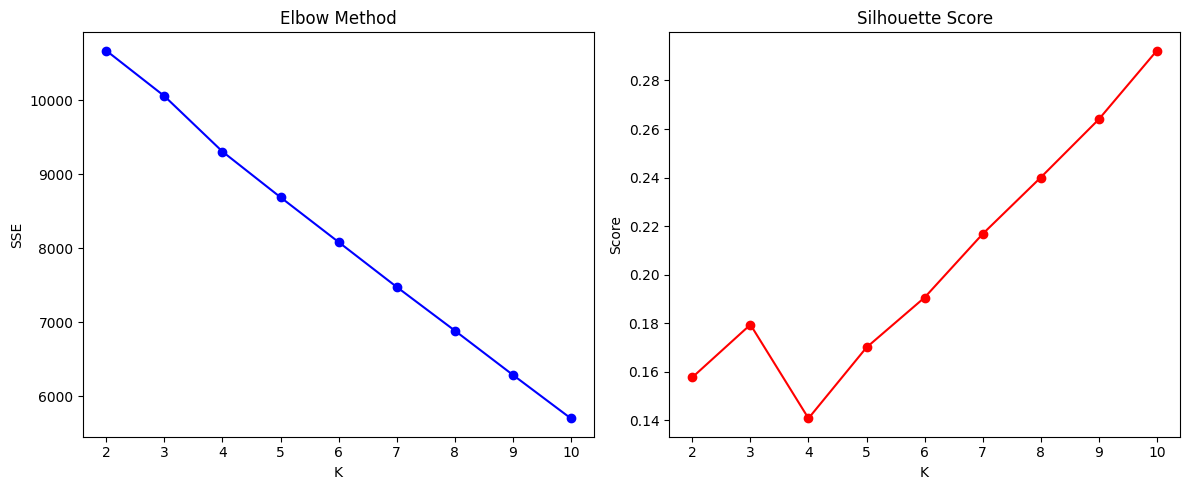

In [9]:
sse = []
sil_scores = []

K_RANGE = range(2, 11)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(x_scaled)
    
    sse.append(km.inertia_)
    sil_scores.append(silhouette_score(x_scaled, labels))

# Plot
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(K_RANGE, sse, "bo-")
plt.title("Elbow Method")
plt.xlabel("K")
plt.ylabel("SSE")

plt.subplot(1,2,2)
plt.plot(K_RANGE, sil_scores, "ro-")
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

In [10]:
# 👉 choose best K based on graph
BEST_K = K_RANGE[np.argmax(sil_scores)]
print("\nBest K based on Silhouette:", BEST_K)   


Best K based on Silhouette: 10


# final k-mean model

In [11]:
kmeans = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(x_scaled)

df['kmeans_cluster'] = kmeans_labels

In [12]:
# cluster validation

print("\nKMeans Evaluation:")
print("Silhouette Score:", silhouette_score(x_scaled, kmeans_labels))
print("Davies-Bouldin Score:", davies_bouldin_score(x_scaled, kmeans_labels))


KMeans Evaluation:
Silhouette Score: 0.2922630923363321
Davies-Bouldin Score: 1.4989979326755623



Explained Variance Ratio: [0.13118305 0.11972589]
Total Variance: 0.250908941034556


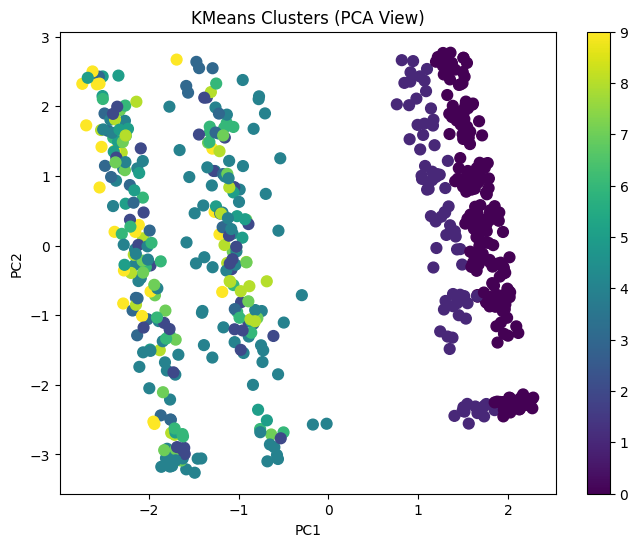

In [13]:
# PCA visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(x_scaled)

print("\nExplained Variance Ratio:", pca.explained_variance_ratio_)
print("Total Variance:", sum(pca.explained_variance_ratio_))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=kmeans_labels, cmap='viridis', s=60)
plt.title("KMeans Clusters (PCA View)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

In [18]:
# cluster profiling
profile_cols = [
    'base_price_lakh',
    'highest_auction_price_lakh',
    'ipl_experience',
    'value_ratio',
    'age',
    'is_capped_international'
]

print("\nCluster Profiles:")
group = df.groupby('kmeans_cluster')[profile_cols].mean().round(2)
display(group)


Cluster Profiles:


,base_price_lakh,highest_auction_price_lakh,ipl_experience,value_ratio,age,is_capped_international
kmeans_cluster,,,,,,
0,90.66,584.78,6.45,0.10,33.83,0.67
1,91.79,578.89,5.48,0.10,33.17,0.67
2,88.75,587.78,5.78,0.10,33.08,0.47
3,111.79,778.39,5.14,0.09,30.00,0.61
4,90.33,498.19,6.56,0.10,32.61,0.60
5,110.91,789.55,6.05,0.08,33.55,0.77
6,100.00,690.81,6.58,0.10,34.23,0.68
7,91.74,506.52,6.91,0.09,36.48,0.65
8,94.04,587.69,4.77,0.09,30.50,0.58


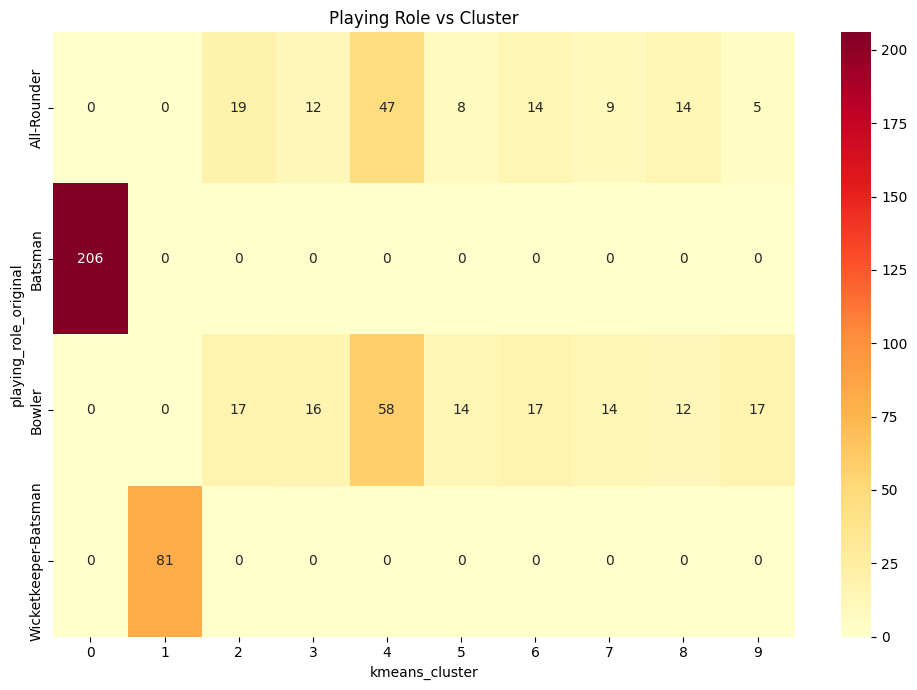

In [19]:
if 'playing_role_original' in df.columns:
    role_cluster = pd.crosstab(df["playing_role_original"], df["kmeans_cluster"])
    plt.figure(figsize=(10,7))
    sns.heatmap(role_cluster, annot=True, fmt="d", cmap="YlOrRd")
    plt.title("Playing Role vs Cluster")
    plt.tight_layout()
    plt.show()
else:
    print("Missing playing_role or kmeans_cluster column")

# cluster label

In [26]:
cluster_labels = {}

# Get cluster means
cluster_summary = df.groupby('kmeans_cluster')[profile_cols].mean()
print("cluster summury")
display(cluster_summary)
# Get thresholds (relative)
price_threshold = cluster_summary['highest_auction_price_lakh'].mean()
value_threshold = cluster_summary['value_ratio'].mean()
experience_threshold = cluster_summary['ipl_experience'].mean()

for cluster in cluster_summary.index:
    row = cluster_summary.loc[cluster]
    
    if (
        row['highest_auction_price_lakh'] > price_threshold and
        row['ipl_experience'] > experience_threshold
    ):
        cluster_labels[cluster] = "Premium"
    
    elif (
        row['value_ratio'] > value_threshold and
        row['base_price_lakh'] < price_threshold
    ):
        cluster_labels[cluster] = "Undervalued"
    
    else:
        cluster_labels[cluster] = "Budget"

print("\nCluster Label Mapping:")
display(cluster_labels)

cluster summury


,base_price_lakh,highest_auction_price_lakh,ipl_experience,value_ratio,age,is_capped_international
kmeans_cluster,,,,,,
0,90.655340,584.781553,6.451456,0.097543,33.834951,0.665049
1,91.790123,578.888889,5.481481,0.097979,33.172840,0.666667
2,88.750000,587.777778,5.777778,0.098326,33.083333,0.472222
3,111.785714,778.392857,5.142857,0.085636,30.000000,0.607143
4,90.333333,498.190476,6.561905,0.101908,32.609524,0.600000
5,110.909091,789.545455,6.045455,0.077268,33.545455,0.772727
6,100.000000,690.806452,6.580645,0.095222,34.225806,0.677419
7,91.739130,506.521739,6.913043,0.094281,36.478261,0.652174
8,94.038462,587.692308,4.769231,0.091520,30.500000,0.576923



Cluster Label Mapping:


{0: 'Undervalued',
 1: 'Undervalued',
 2: 'Undervalued',
 3: 'Budget',
 4: 'Undervalued',
 5: 'Premium',
 6: 'Premium',
 7: 'Undervalued',
 8: 'Budget',
 9: 'Budget'}

In [24]:
df['player_category'] = df['kmeans_cluster'].map(cluster_labels)
print(df['player_category'].value_counts())

player_category
Undervalued    451
Budget          76
Premium         53
Name: count, dtype: int64


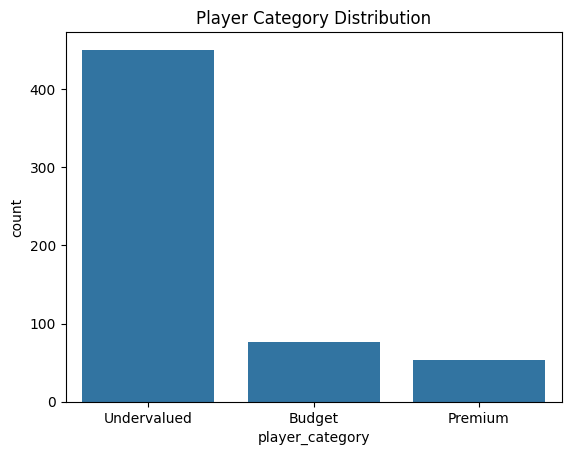

In [25]:
sns.countplot(x='player_category', data=df)
plt.title("Player Category Distribution")
plt.show()

# DBSCAN

In [42]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
db_labels = dbscan.fit_predict(x_scaled)

df['dbscan_cluster'] = db_labels

print("\nDBSCAN Clusters:")
print(pd.Series(db_labels).value_counts())

# Remove noise (-1) for evaluation
if len(set(db_labels)) > 1 and -1 not in set(db_labels):
    print("DBSCAN Silhouette:", silhouette_score(x_scaled, db_labels))


DBSCAN Clusters:
-1    336
 0     91
 1     40
 3     40
 2     37
 9      8
 8      7
 4      6
 6      5
 5      5
 7      5
Name: count, dtype: int64


In [56]:
df

,is_capped_international,base_price_lakh,highest_auction_price_lakh,age,ipl_experience,log_highest_price,playing_role_Batsman,playing_role_Bowler,playing_role_Wicketkeeper-Batsman,batting_style_Right-hand bat,...,bowling_style_Left-arm orthodox,bowling_style_Left-arm wrist spin,bowling_style_No Bowling,bowling_style_Right-arm fast,bowling_style_Right-arm fast-medium,bowling_style_Right-arm leg break,bowling_style_Right-arm medium,bowling_style_Right-arm offbreak,bowling_style_Slow left-arm orthodox,kmeans_cluster
0,1,75,100,44,10,4.615121,True,False,False,True,...,False,False,True,False,False,False,False,False,False,2
1,0,100,405,34,8,6.006353,False,True,False,True,...,False,False,False,False,False,False,False,False,True,1
2,1,20,105,23,1,4.663439,False,False,False,True,...,False,False,False,False,False,False,False,False,False,1
3,1,50,505,35,9,6.226537,True,False,False,True,...,False,False,True,False,False,False,False,False,False,2
4,1,200,710,23,2,6.566672,False,True,False,False,...,False,False,False,True,False,False,False,False,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
575,1,200,2125,41,11,7.661998,True,False,False,True,...,False,False,True,False,False,False,False,False,False,2
576,0,100,150,47,15,5.017280,False,False,True,True,...,False,False,True,False,False,False,False,False,False,3
577,1,40,410,44,10,6.018593,True,False,False,True,...,False,False,True,False,False,False,False,False,False,2
578,0,50,495,22,2,6.206576,True,False,False,True,...,False,False,True,False,False,False,False,False,False,2
